# Rehan Khan || 221A059 || 21


## 1. Import dependencies


In [ ]:
# Rehan Khan || 221A059
import os
import gymnasium as gym
import numpy as np

## 2. Load environment


In [ ]:
# Rehan Khan || 221A059
env = gym.make("Taxi-v3",render_mode="rgb_array")
state = env.reset()
state

(264, {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

In [ ]:
env.observation_space.n

np.int64(500)

In [ ]:
env.action_space.n

np.int64(6)

array([[[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[110, 109, 106],
        [110, 109, 106],
        [124, 122, 122],
        ...,
        [108, 111, 109],
        [108, 111, 109],
        [118, 119, 119]],

       [[114, 116, 115],
        [114, 116, 115],
        [126, 127, 126],
        ...,
        [112, 113, 111],
        [112, 113, 111],
        [118, 117, 115]],

       ...,

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[116, 115, 116],
        [116, 115, 116],
        [106, 107, 108],
        ...,
        [113, 115, 114],
        [113, 115, 114],
        [117, 114, 117]],

       [[115, 112, 112],
        [115, 112, 112],
        [119, 119, 117],
        ...,
        [123, 119, 118],
        [123, 119, 118],
        [114, 114, 117]]], dtype=uint8)
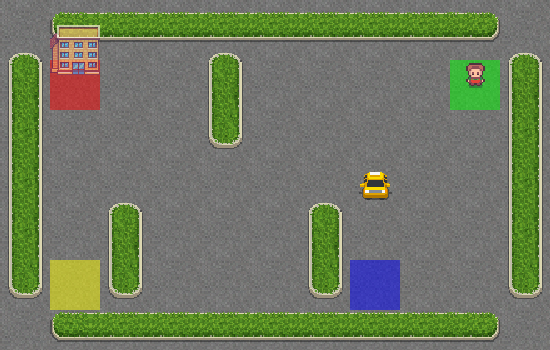

In [ ]:
env.render()

In [ ]:
env.step(4)

(264,
 -10,
 False,
 False,
 {'prob': 1.0, 'action_mask': array([1, 1, 1, 1, 0, 0], dtype=int8)})

## Possible actions
down(0), up(1), right(2), left (3), pick-up(4) and drop-off(5)

In [ ]:

# Rehan Khan || 221A059n_states=env.observation_space.n
n_actions=env.action_space.n

n_actions


np.int64(6)

## How good does behaving completely random do ?

In [ ]:
# Rehan Khan || 221A059state=env.reset()
counter=0
g=0
reward=None

In [ ]:
while reward != 20:
    state,reward,terminated,truncated,info=env.step(env.action_space.sample())
    counter+=1
    g+=reward

In [ ]:
print("Solved in {} Steps with a total reward of {}".format(counter,g))

Solved in 438 Steps with a total reward of -1857


## Let's look at just one episode and see how the Q values change after each step using the formula below
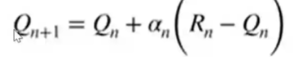

In [ ]:
Q=np.zeros([n_states,n_actions])
print(n_actions)

6


In [ ]:
episodes=50
G=0
alpha=0.618


In [ ]:
# Rehan Khan || 221A059for episode in range(1, episodes+1):
  steps_q_learning = 0
  G, reward=0,0
  state, _ = env.reset()
  state = int(state)
  finalState=state
  print(f"Initial state {state}")
  while reward != 20:
      action=np.argmax(Q[state])
      state2_tuple, reward, terminated, truncated, info  = env.step(action)
      state2 = int(state2_tuple)
      Q[state, action] = Q[state, action] + alpha * (reward + np.max(Q[state2]) - Q[state, action])
      G += reward
      steps_q_learning += 1
      state=state2
  print(f"Episode {episode} solved in {steps_q_learning} steps with a total reward of {G}")

Initial state 353
Episode 1 solved in 148 steps with a total reward of -127
Initial state 402
Episode 2 solved in 12 steps with a total reward of 9
Initial state 1
Episode 3 solved in 10 steps with a total reward of 11
Initial state 93
Episode 4 solved in 27 steps with a total reward of -6
Initial state 301
Episode 5 solved in 62 steps with a total reward of -149
Initial state 169
Episode 6 solved in 81 steps with a total reward of -60
Initial state 453
Episode 7 solved in 49 steps with a total reward of -28
Initial state 383
Episode 8 solved in 36 steps with a total reward of -15
Initial state 204
Episode 9 solved in 50 steps with a total reward of -29
Initial state 301
Episode 10 solved in 58 steps with a total reward of -127
Initial state 443
Episode 11 solved in 43 steps with a total reward of -22
Initial state 249
Episode 12 solved in 61 steps with a total reward of -40
Initial state 327
Episode 13 solved in 89 steps with a total reward of -284
Initial state 472
Episode 14 solved 

In [ ]:
finalState

287

In [ ]:
G

12

## After 1 episode of implementing Q learnign total reward is better than random approach

## This way we get the optimal policy solution (agent learnt the optimal policy)